# **Detector de Fraude**

<div align="justify">

No mundo real, as transações financeiras são, em sua esmagadora maioria, legítimas. A fraude é uma anomalia (geralmente representando menos de 1% do volume total).

**O Dilema do Negócio:**

*    Falsos Negativos (Deixar a fraude passar): Custo direto para a empresa, que muitas vezes precisa reembolsar o cliente fraudado, além de gerar multas regulatórias e perda de confiança.

*   Falsos Positivos (Bloquear uma transação legítima): Atrito imenso. Se você bloqueia o cartão de um bom cliente no meio de um jantar, ele pode cancelar a conta e ir para o concorrente.

</div>

<div align="justify">

**A Armadilha do Desbalanceamento:**

Se 99,9% das transações são legítimas, um modelo "preguiçoso" que simplesmente diz que nenhuma transação é fraude terá 99,9% de acurácia. Para o negócio, porém, a utilidade desse modelo é zero. É por isso que não usamos a "Acurácia" como métrica principal aqui, mas sim o Recall (capacidade de encontrar as fraudes) e a Precisão (quando diz que é fraude, acertar).

**A Solução com SMOTE:**

O SMOTE (Synthetic Minority Over-sampling Technique) resolve esse desbalanceamento criando "clones inteligentes" (dados sintéticos) da classe minoritária (as fraudes) usando vizinhos mais próximos. Assim, o modelo tem exemplos suficientes para aprender os padrões criminosos sem ficar enviesado pela maioria de transações boas.

</div>

**1. IMPORTANDO AS BIBLIOTECAS DO PROJETO**

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning e Pré-processamento
from sklearn.model_selection import train_test_split # Divisão do conjunto de dados em subconjuntos de treino e teste
from sklearn.preprocessing import StandardScaler # Padronização das variáveis (escalonamento dos dados para média 0 e variância 1)
from sklearn.ensemble import RandomForestClassifier # Algoritmo de machine learning para classificação (Modelo de Floresta Aleatória)
from imblearn.over_sampling import SMOTE # Técnica de balanceamento de classes (gera amostras sintéticas para a classe minoritária)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve # Métricas para avaliar o desempenho e os acertos/erros do modelo
from xgboost import XGBClassifier

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

**2. CARREGAMENTO E ENTENDIMENTO DOS DADOS**

In [55]:
print("Carregando os dados...\n")

df = pd.read_csv("AIML Dataset.csv") # Carregando o dataset

print("Entendendo os dados:")

df.head() # Visualizando as primeiras linhas do dataset

Carregando os dados...

Entendendo os dados:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [56]:
df.info() # Visualizando informações do dataset

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [57]:
df.describe() # Visualizando estatísticas descritivas do dataset

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


Verificando Valores Nulos/Duplicados:

In [58]:
def diagnostico(df):
  print(f"--- Diagnóstico ---")
  print("\nValores nulos por coluna:\n")
  display(df.isnull().sum())
  print("\nDuplicados:", df.duplicated().sum())

diagnostico(df)

--- Diagnóstico ---

Valores nulos por coluna:



step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Duplicados: 0


**3. ANÁLISE EXPLORATÓRIA (GRÁFICOS INICIAIS)**

C:\Users\conta\AppData\Local\Temp\ipykernel_12476\136667840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='isFraud', data=df, palette='Set2')


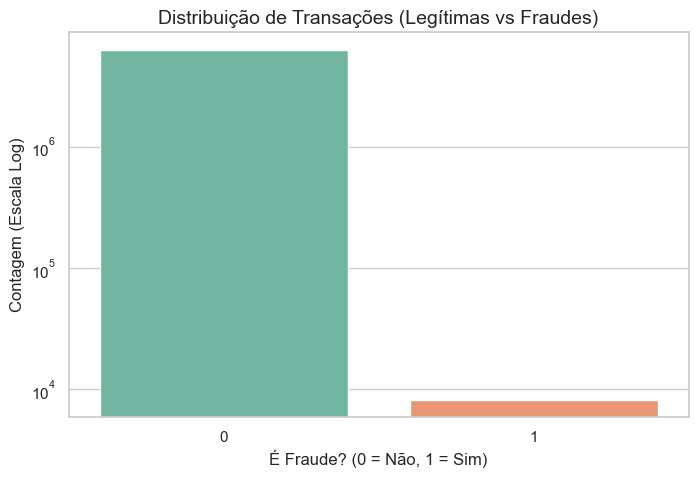

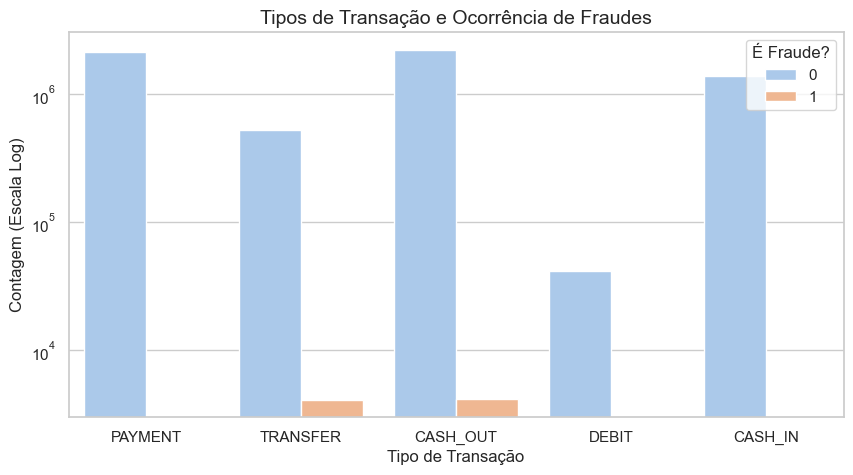

In [59]:
# Gráfico 1: Desbalanceamento das Classes
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='isFraud', data=df, palette='Set2')
plt.title('Distribuição de Transações (Legítimas vs Fraudes)', fontsize=14)
plt.yscale('log') # Escala logarítmica porque a diferença é brutal
plt.xlabel('É Fraude? (0 = Não, 1 = Sim)')
plt.ylabel('Contagem (Escala Log)')
plt.show()

# Gráfico 2: Tipos de Transação
plt.figure(figsize=(10, 5))
sns.countplot(x='type', hue='isFraud', data=df, palette='pastel')
plt.title('Tipos de Transação e Ocorrência de Fraudes', fontsize=14)
plt.yscale('log')
plt.xlabel('Tipo de Transação')
plt.ylabel('Contagem (Escala Log)')
plt.legend(title='É Fraude?')
plt.show()

**PAYMENT:** é o processo de pagar por bens ou serviços a comerciantes, o que diminui o saldo da conta e aumenta o saldo do recebedor.

**TRANSFER:** é o processo de enviar dinheiro para outro usuário do serviço por meio da plataforma de dinheiro móvel.

**CASH-OUT:** é o processo inverso de DEPÓSITO, ou seja, retirar dinheiro de um estabelecimento comercial, o que diminui o saldo da conta.

**DEBIT:** é um processo semelhante ao SAQUE e envolve o envio de dinheiro do serviço de dinheiro móvel para uma conta bancária.

**CASH-IN:** é o processo de aumentar o saldo da conta pagando em dinheiro a um comerciante.

**4. ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING)**

In [60]:
# O dataset usa "step" que mapeia 1 step = 1 hora. Assim, extrair a "hora do dia" (0 a 23).
df['hora_do_dia'] = df['step'] % 24

# Diferença de saldo esperada vs real 
# Se eu transferi 100, meu novo saldo tem que ser o saldo antigo menos 100. Se for diferente, é suspeito!
df['erro_saldo_origem'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['erro_saldo_destino'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

**5. PRÉ-PROCESSAMENTO**

In [61]:
# Removendo colunas de identificação textual que não servem para o modelo
colunas_para_remover = ['nameOrig', 'nameDest', 'isFlaggedFraud']
df = df.drop(columns=colunas_para_remover)

# Transformando a variável categórica 'type' em numérica (One-Hot Encoding)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Separando X (features) e y (target)
X = df.drop(columns=['isFraud'])
y = df['isFraud']

**6. DIVISÃO E BALANCEAMENTO (SMOTE)**

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Separando treino e teste

# Aplicando SMOTE apenas no conjunto de treino
smote = SMOTE(sampling_strategy='minority', random_state=42) 
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

**7. TREINAMENTO DO MODELO RANDOM FOREST**

In [63]:
# Random Forest é excelente para fraudes porque captura relações não lineares complexas.
# n_estimators=50 para acelerar, mas em produção pode ser 100 ou mais.

modelo = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
modelo.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

**8. AVALIAÇÃO DO MODELO (O TESTE REAL)**

In [65]:
print("Avaliando o modelo nos dados de teste (dados invisíveis para o modelo):")

y_pred = modelo.predict(X_test)

print("\n--- MATRIZ DE CONFUSÃO ---")
# Mostra exatamente onde o modelo acertou e onde errou (Falsos Positivos vs Falsos Negativos)
print(confusion_matrix(y_test, y_pred))

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO ---")
# Foca nas métricas da classe '1' (Fraude). Olhe principalmente para o Recall e o F1-Score.
print(classification_report(y_test, y_pred))

Avaliando o modelo nos dados de teste (dados invisíveis para o modelo):

--- MATRIZ DE CONFUSÃO ---
[[1270867      14]
 [      4    1639]]

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.99      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



**10. TREINAMENTO DO MODELO: XGBOOST**

In [66]:
# XGBoost é mais rápido e poderoso que a Random Forest.
modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1, # Usa todos os núcleos do processador
    eval_metric='logloss'
)

modelo_xgb.fit(X_train_resampled, y_train_resampled)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

**11. AVALIAÇÃO COM GRÁFICOS E THRESHOLD**

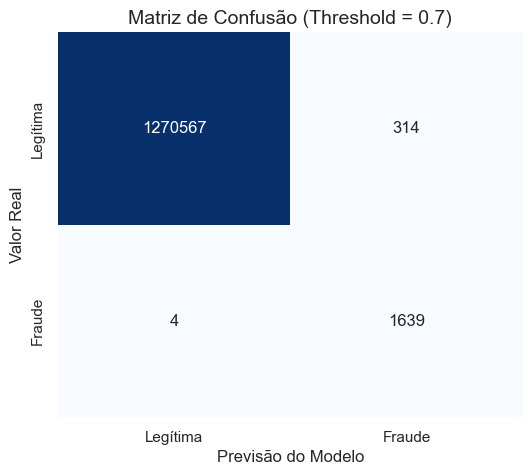

\n--- RELATÓRIO DE CLASSIFICAÇÃO (THRESHOLD 0.7) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.84      1.00      0.91      1643

    accuracy                           1.00   1272524
   macro avg       0.92      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524



C:\Users\conta\AppData\Local\Temp\ipykernel_12476\634922918.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index, palette='viridis')


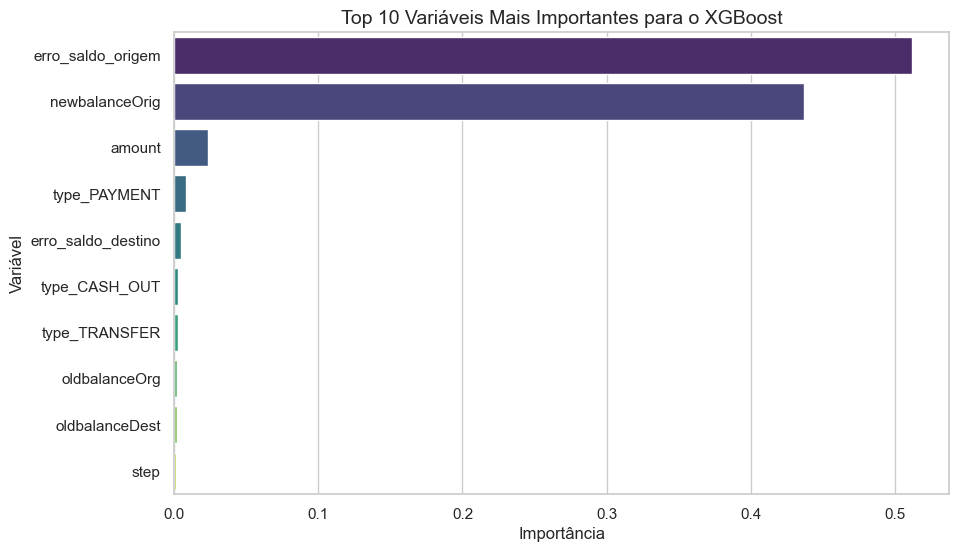

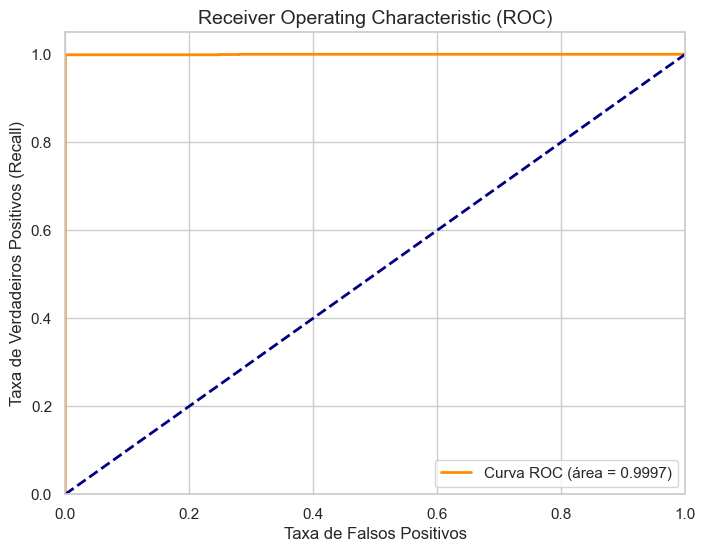

In [67]:
# Em vez de pegar a classe final (0 ou 1), pegamos a PROBABILIDADE de ser 1 (Fraude)
y_pred_proba = modelo_xgb.predict_proba(X_test)[:, 1]

# Calibração de Threshold (Ponto de Corte)
# Padrão é 0.5 (50%). Então irei ser mais conservadores para reduzir Falsos Positivos e usar 0.7 (70%).
# Ou seja, o modelo só diz que é fraude se tiver 70%+ de certeza.
threshold_customizado = 0.70
y_pred_custom = (y_pred_proba >= threshold_customizado).astype(int)

# Gráfico 3: Matriz de Confusão com Heatmap
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legítima', 'Fraude'], 
            yticklabels=['Legítima', 'Fraude'])
plt.title(f'Matriz de Confusão (Threshold = {threshold_customizado})', fontsize=14)
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

# Relatório de Classificação
print(f"\\n--- RELATÓRIO DE CLASSIFICAÇÃO (THRESHOLD {threshold_customizado}) ---")
print(classification_report(y_test, y_pred_custom))

# Gráfico 4: Importância das Variáveis (Feature Importance)
# Mostra quais colunas foram mais decisivas para encontrar a fraude
plt.figure(figsize=(10, 6))
importancias = pd.Series(modelo_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importancias.head(10).values, y=importancias.head(10).index, palette='viridis')
plt.title('Top 10 Variáveis Mais Importantes para o XGBoost', fontsize=14)
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

# Gráfico 5: Curva ROC
# Avalia a capacidade geral do modelo de separar as classes
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.show()

<div align="justify">
A detecção de fraudes em transações financeiras representa um dos maiores desafios e necessidades críticas para instituições bancárias e empresas de pagamento na atualidade. Como abordado no projeto, a fraude é uma anomalia, geralmente representando menos de 1% do volume total de transações. A importância de desenvolver um modelo preditivo eficaz reside na resolução do chamado "Dilema do Negócio", que consiste em equilibrar o impacto dos falsos negativos (deixar a fraude passar, o que gera custos diretos de reembolso e possíveis multas) e dos falsos positivos (bloquear uma transação legítima, causando um imenso atrito e perda de confiança do cliente).
<br><br>
Para superar a armadilha do desbalanceamento dos dados, onde focar apenas na Acurácia entregaria resultados enganosos, o projeto obteve sucesso ao priorizar as métricas de Recall e Precisão. Resultados consistentes foram alcançados graças à aplicação da técnica SMOTE, que criou "clones inteligentes" da classe minoritária (fraudes), permitindo que os modelos aprendessem os padrões criminosos de forma justa e sem o viés da maioria de transações legítimas. A utilização de algoritmos avançados, como Random Forest e XGBoost, provou-se altamente capaz de lidar com essa complexidade. Além disso, a estratégia de definir um threshold (ponto de corte) customizado de 0.70 mostrou-se um excelente refinamento, garantindo que o sistema só sinalize uma fraude quando tiver 70% ou mais de certeza, mitigando fortemente o bloqueio indevido de bons clientes.
<br><br>
A utilidade prática deste desenvolvimento no mundo corporativo é imensa. Ao ser implementado em um ambiente de produção, este modelo atua como uma poderosa camada de defesa em tempo real, capaz de processar e avaliar o risco de milhares de transações por segundo. Para o negócio, isso se traduz em uma diminuição significativa de perdas financeiras por golpes e na otimização do trabalho das equipes de análise de fraude, que passam a investigar apenas os alertas mais críticos e precisos. Em suma, o projeto entrega uma solução tecnológica robusta que protege o patrimônio da empresa e, simultaneamente, preserva a experiência de uso do cliente legítimo, fator vital para a competitividade no mercado financeiro moderno.
</div>
